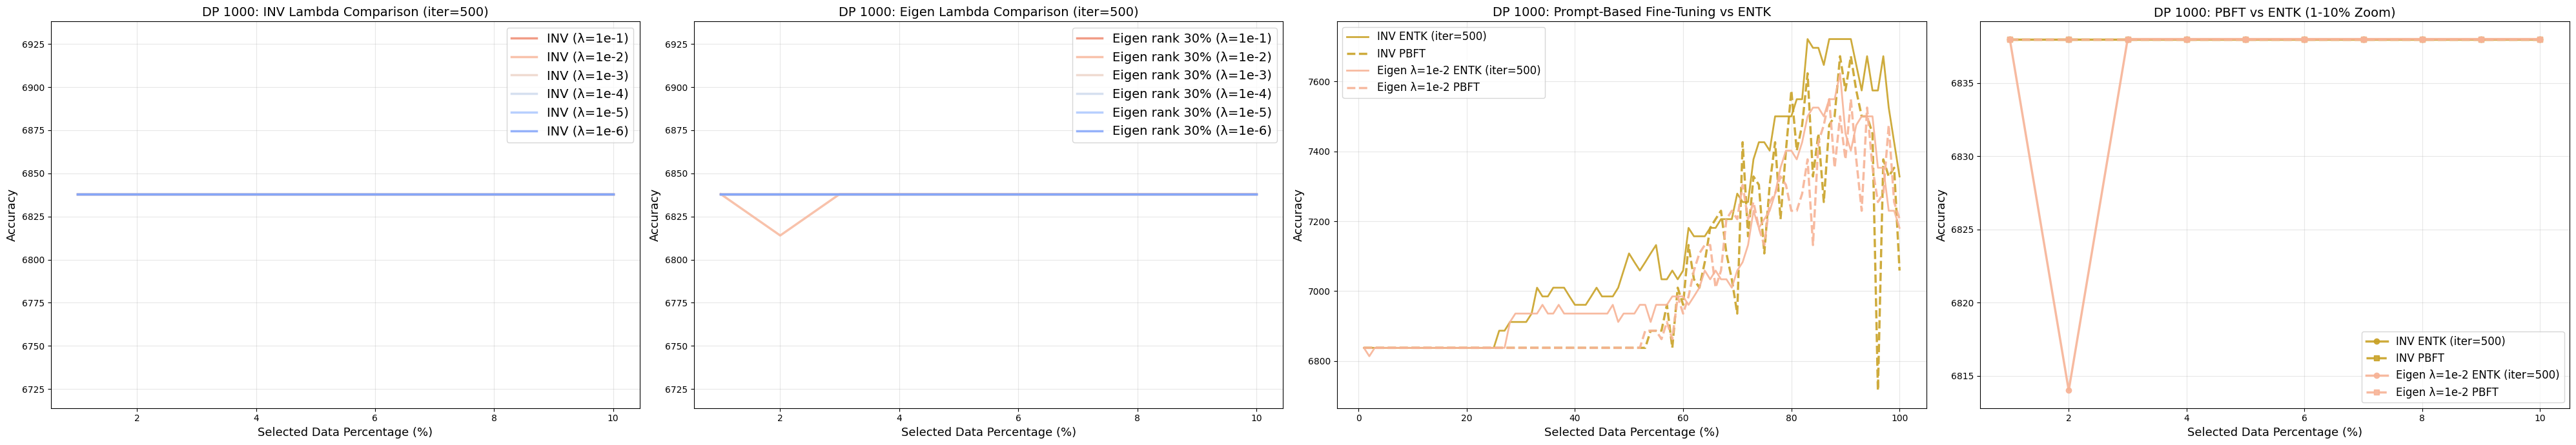

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6887, 6887, 6912, 6912, 6912, 6912, 6936, 7010, 6985, 6985, 7010, 7010, 7010, 6985, 6961, 6961, 6961, 6985, 7010, 6985, 6985, 6985, 7010, 7059, 7108, 7083, 7059, 7083, 7108, 7132, 7034, 7034, 7059, 7034, 7059, 7181, 7157, 7157, 7157, 7181, 7181, 7206, 7206, 7206, 7279, 7255, 7255, 7377, 7426, 7426, 7402, 7500, 7500, 7500, 7500, 7549, 7549, 7721, 7696, 7696, 7647, 7721, 7721, 7721, 7721, 7721, 7647, 7574, 7672, 7574, 7574, 7672, 7525, 7426, 7328]
inv_lam1e_5      = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6887, 6887, 6887, 6912, 6912, 6936, 6936, 6936, 7010, 6985, 7010, 7010, 7010, 7010, 6985, 6961, 6961, 6961, 6985, 6985, 6985, 6985, 6985, 7010, 7059, 7059, 7083, 7059, 7083, 7059, 7083, 7132, 7034, 7083, 7034, 7034, 7132, 7157, 7157, 7157, 7181, 7181, 7157, 7206, 7206, 7279, 7255, 7255, 7377, 7426, 7426, 7402, 7500, 7500, 7426, 7500, 7549, 7549, 7647, 7696, 7696, 7647, 7721, 7721, 7721, 7721, 7721, 7647, 7574, 7672, 7574, 7525, 7672, 7525, 7426, 7328]  
inv_lam1e_4      = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6912, 6912, 6936, 6936, 6912, 7010, 6985, 6985, 6985, 7010, 7010, 6985, 6985, 6961, 6985, 6985, 6985, 6985, 6985, 6985, 7059, 7059, 7108, 7083, 7108, 7108, 7108, 7083, 7034, 7059, 7083, 7059, 7059, 7132, 7132, 7181, 7157, 7181, 7157, 7181, 7181, 7255, 7206, 7255, 7279, 7353, 7451, 7451, 7426, 7451, 7500, 7426, 7525, 7549, 7525, 7647, 7647, 7696, 7647, 7721, 7745, 7721, 7721, 7623, 7647, 7623, 7672, 7574, 7549, 7672, 7525, 7426, 7328]
inv_lam1e_3      = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6912, 6912, 7010, 7010, 7010, 7034, 7034, 7034, 7034, 6985, 6985, 6985, 7010, 7010, 7010, 6985, 6985, 6985, 6985, 7010, 7010, 7010, 7083, 7083, 7083, 7083, 7083, 7083, 7108, 7108, 7108, 7059, 7034, 7108, 7108, 7132, 7132, 7132, 7181, 7157, 7230, 7206, 7230, 7230, 7230, 7304, 7304, 7279, 7353, 7377, 7451, 7475, 7525, 7500, 7525, 7574, 7549, 7696, 7696, 7745, 7696, 7745, 7745, 7794, 7745, 7623, 7672, 7672, 7647, 7672, 7647, 7525, 7426, 7328]  
inv_lam1e_2      = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6887, 6912, 6887, 6887, 6887, 6912, 6912, 6912, 6912, 6912, 6936, 6985, 6985, 6961, 6961, 6936, 7010, 7034, 7010, 7010, 7010, 7010, 7010, 7083, 7059, 7059, 7034, 7034, 7059, 7059, 7059, 7083, 7083, 7083, 7083, 7083, 7059, 7059, 7083, 7108, 7132, 7132, 7132, 7132, 7059, 7083, 7132, 7181, 7132, 7206, 7132, 7157, 7181, 7353, 7402, 7451, 7475, 7525, 7525, 7500, 7574, 7574, 7574, 7525, 7525, 7721, 7721, 7819, 7794, 7672, 7770, 7745, 7696, 7598, 7623, 7721, 7672, 7574, 7574, 7574, 7574, 7377] 
inv_lam1e_1      = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6863, 6863, 6863, 6863, 6863, 6863, 6838, 6838, 6838, 6961, 6985, 6985, 6961, 7034, 7010, 6985, 6985, 6985, 6985, 6985, 6985, 6961, 6961, 6961, 6961, 6961, 6961, 6961, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 6985, 7034, 7010, 7010, 7010, 7010, 7010, 7059, 7083, 7157, 7132, 7108, 7132, 7108, 7132, 7206, 7230, 7328, 7304, 7328, 7328, 7353, 7377, 7525, 7500, 7475, 7451, 7451, 7500, 7525, 7647, 7647, 7647, 7647, 7672, 7647, 7647, 7574, 7745, 7672, 7672, 7647, 7574, 7475, 7451, 7206]  
eigen_lam1e_6    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6814, 6814, 6838, 6838, 6838, 6814, 6912, 6912, 6961, 6936, 6961, 6985, 6961, 6936, 7010, 7010, 6985, 6863, 7010, 6961, 6936, 6912, 6912, 6961, 6985, 6985, 7010, 6985, 6961, 6912, 6887, 6936, 7010, 6961, 7010, 6936, 6985, 7034, 7010, 6961, 6936, 6961, 6887, 6936, 6985, 6936, 6936, 6936, 6961, 6912, 6936, 6985, 7059, 7010, 7010, 7034, 7034, 7034, 7034, 7059, 7108, 7206, 7255, 7304, 7304, 7328, 7402, 7377, 7426, 7426, 7353, 7304, 7328, 7549, 7426, 7525, 7426, 7426, 7426, 7377, 7426, 7525, 7402, 7377, 7304, 7255, 7230, 7181]
eigen_lam1e_5    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6814, 6838, 6838, 6838, 6838, 6838, 6814, 6814, 6814, 6961, 6961, 6961, 6936, 6936, 6912, 6887, 6838, 6716, 6495, 6961, 7083, 7059, 7010, 7034, 6985, 6961, 6936, 6936, 6936, 6887, 6985, 6985, 6961, 6961, 6961, 7010, 7010, 6985, 6961, 7108, 7034, 7034, 7034, 7010, 6961, 6961, 6961, 6985, 6961, 7034, 7059, 7010, 7034, 7059, 7010, 7010, 7010, 7010, 7059, 7108, 7157, 7206, 7230, 7255, 7328, 7377, 7353, 7402, 7426, 7426, 7402, 7451, 7475, 7525, 7451, 7549, 7500, 7426, 7353, 7402, 7500, 7426, 7353, 7353, 7304, 7255, 7230, 7181]
eigen_lam1e_4    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6814, 6814, 6912, 6936, 6936, 6936, 6985, 7010, 7010, 6936, 6912, 7010, 6985, 6961, 7108, 7132, 7132, 7132, 7108, 6936, 6912, 6961, 6961, 6936, 6887, 6985, 6985, 6985, 7010, 6936, 6961, 7010, 7010, 7010, 7010, 7010, 7034, 7034, 7034, 7059, 7059, 7034, 7034, 7059, 7059, 6961, 6936, 7010, 7034, 7034, 7010, 7034, 7034, 7034, 7157, 7132, 7230, 7279, 7451, 7353, 7328, 7377, 7377, 7426, 7402, 7500, 7402, 7328, 7451, 7574, 7574, 7500, 7353, 7451, 7475, 7426, 7426, 7377, 7377, 7304, 7279, 7230, 7181]
eigen_lam1e_3    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6814, 6814, 6838, 6814, 6814, 6814, 6814, 6814, 6814, 6814, 6814, 6838, 6814, 6887, 6912, 6912, 6838, 6936, 6936, 6912, 6985, 6887, 6887, 6814, 6789, 6838, 6765, 6961, 6961, 6936, 6936, 6936, 6961, 6961, 6961, 6936, 6961, 6961, 6961, 6985, 6985, 7034, 7034, 6985, 7010, 7010, 7083, 7034, 7034, 7010, 7059, 6985, 7010, 7034, 7010, 7083, 7132, 7059, 7108, 7132, 7083, 7108, 7206, 7181, 7230, 7353, 7328, 7353, 7353, 7451, 7353, 7426, 7500, 7525, 7623, 7623, 7549, 7525, 7475, 7328, 7328, 7304, 7377, 7426, 7451, 7304, 7279, 7206, 7279, 7181]
eigen_lam1e_2    = [6838, 6814, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6912, 6936, 6936, 6936, 6936, 6936, 6961, 6936, 6936, 6961, 6936, 6936, 6936, 6936, 6936, 6936, 6936, 6936, 6936, 6961, 6912, 6936, 6936, 6936, 6961, 6961, 6912, 6961, 6961, 6961, 6985, 6985, 6985, 6961, 6985, 7010, 7059, 7034, 7059, 7034, 7034, 7010, 7059, 7083, 7132, 7230, 7181, 7206, 7230, 7279, 7353, 7402, 7402, 7377, 7426, 7500, 7525, 7525, 7500, 7549, 7549, 7623, 7451, 7402, 7475, 7500, 7500, 7500, 7353, 7353, 7230, 7230, 7181]
eigen_lam1e_1    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6863, 6863, 6863, 6863, 6863, 6863, 6912, 6912, 6912, 6912, 6912, 6887, 6887, 6863, 6863, 6863, 6961, 6985, 6961, 6961, 6961, 6961, 6961, 6936, 6912, 6961, 6961, 6961, 6961, 6936, 6936, 6961, 6961, 6936, 6936, 6912, 6936, 6912, 6912, 6912, 6912, 6912, 6936, 6936, 6961, 6961, 6936, 6936, 6961, 6961, 6961, 6961, 7010, 7010, 7034, 7083, 7034, 7059, 7059, 7108, 7059, 7108, 7083, 7206, 7157, 7304, 7304, 7377, 7426, 7500, 7500, 7549, 7525, 7500, 7525, 7549, 7500, 7549, 7475, 7525, 7500, 7574, 7500, 7377, 7206, 7279]

# Prediction with random shapley values
r_inv_lam1e_6     = [6961, 6544, 6642, 6765, 6691, 6544, 6593, 6936, 6863, 6789, 6814, 6765, 6887, 6936, 6912, 6985, 6985, 6961, 6985, 7059, 6863, 6961, 7108, 7132, 6961, 6985, 6985, 7059, 7034, 7034, 7059, 7181, 7181, 7328, 7181, 7230, 7255, 7059, 7181, 7255, 7108, 7255, 7157, 7132, 7157, 7083, 7108, 7059, 7132, 7206, 7059, 7157, 7181, 7157, 7157, 7010, 7010, 7010, 7010, 6985, 7034, 7059, 7059, 7255, 7108, 7132, 7108, 7181, 7132, 7255, 7206, 7181, 7132, 7157, 7132, 7059, 7206, 7206, 7181, 7181, 7255, 7230, 7304, 7279, 7304, 7255, 7255, 7279, 7353, 7328, 7377, 7451, 7304, 7304, 7304, 7304, 7230, 7230, 7328, 7328]
r_inv_lam1e_5     = [6961, 6544, 6642, 6765, 6691, 6544, 6593, 6936, 6863, 6789, 6814, 6765, 6887, 6936, 6912, 6985, 6985, 6961, 6985, 7059, 6863, 6961, 7108, 7132, 6961, 6985, 6985, 7059, 7034, 7034, 7059, 7181, 7181, 7328, 7181, 7230, 7255, 7059, 7181, 7255, 7108, 7255, 7157, 7132, 7157, 7083, 7108, 7059, 7132, 7206, 7059, 7157, 7181, 7157, 7157, 7010, 7010, 7010, 7010, 6985, 7034, 7059, 7059, 7255, 7108, 7132, 7108, 7181, 7132, 7255, 7206, 7181, 7132, 7157, 7132, 7059, 7206, 7206, 7181, 7181, 7255, 7230, 7304, 7279, 7304, 7255, 7255, 7279, 7353, 7328, 7377, 7451, 7304, 7304, 7304, 7304, 7230, 7230, 7328, 7328] 
r_inv_lam1e_4     = [6961, 6544, 6642, 6765, 6691, 6544, 6593, 6936, 6863, 6789, 6814, 6765, 6887, 6936, 6912, 6985, 6985, 6961, 6985, 7059, 6863, 6961, 7108, 7132, 6961, 6985, 6985, 7059, 7083, 7034, 7059, 7181, 7206, 7328, 7181, 7230, 7255, 7059, 7181, 7255, 7108, 7255, 7157, 7132, 7157, 7083, 7083, 7034, 7132, 7206, 7059, 7157, 7181, 7157, 7157, 7010, 7010, 7010, 7010, 6985, 7034, 7059, 7059, 7255, 7108, 7132, 7108, 7157, 7132, 7255, 7206, 7181, 7132, 7132, 7132, 7059, 7206, 7206, 7181, 7181, 7255, 7230, 7304, 7279, 7304, 7255, 7255, 7279, 7353, 7328, 7377, 7451, 7304, 7304, 7304, 7304, 7230, 7230, 7328, 7328] 
r_inv_lam1e_3     = [6961, 6544, 6642, 6765, 6667, 6544, 6593, 6936, 6863, 6789, 6814, 6765, 6887, 6961, 6912, 6985, 6985, 6961, 6985, 7059, 6863, 6961, 7132, 7132, 6961, 6985, 6985, 7034, 7083, 7034, 7059, 7181, 7230, 7328, 7181, 7230, 7279, 7059, 7181, 7230, 7108, 7255, 7132, 7132, 7157, 7083, 7083, 7034, 7132, 7206, 7083, 7157, 7157, 7157, 7181, 6985, 6985, 7010, 7010, 6985, 7059, 7083, 7059, 7255, 7108, 7132, 7059, 7157, 7132, 7255, 7230, 7181, 7132, 7157, 7157, 7108, 7206, 7206, 7181, 7181, 7206, 7206, 7304, 7255, 7304, 7279, 7255, 7279, 7353, 7304, 7402, 7451, 7279, 7304, 7304, 7304, 7230, 7230, 7353, 7328]
r_inv_lam1e_2     = [6936, 6593, 6667, 6814, 6716, 6520, 6667, 6936, 6863, 6789, 6887, 6789, 6912, 6985, 6936, 7010, 7010, 6985, 6961, 7132, 6912, 6961, 7108, 7230, 6985, 7010, 7010, 7059, 7059, 7010, 7157, 7206, 7230, 7328, 7181, 7230, 7279, 7059, 7132, 7328, 7132, 7181, 7132, 7108, 7132, 7157, 7157, 7083, 7181, 7255, 7083, 7108, 7157, 7157, 7181, 7083, 7034, 7059, 7034, 7010, 7108, 7132, 7083, 7255, 7059, 7083, 7010, 7132, 7132, 7181, 7255, 7132, 7132, 7083, 7059, 7157, 7157, 7230, 7206, 7181, 7181, 7181, 7304, 7279, 7328, 7255, 7279, 7304, 7353, 7279, 7377, 7377, 7230, 7377, 7304, 7279, 7304, 7328, 7426, 7377] 
r_inv_lam1e_1     = [6912, 6691, 6642, 6838, 6765, 6765, 6887, 6887, 6814, 6936, 6961, 6961, 6838, 6936, 7059, 7010, 7132, 7157, 7132, 7181, 7083, 7083, 7181, 7353, 7132, 7157, 7181, 7206, 7255, 7181, 7279, 7279, 7279, 7279, 7255, 7157, 7206, 7206, 7206, 7206, 7230, 7328, 7353, 7279, 7279, 7328, 7279, 7255, 7206, 7157, 7132, 7108, 7157, 7059, 7059, 7083, 7132, 7181, 7108, 7181, 7230, 7206, 7206, 7181, 7034, 7108, 7108, 7157, 7206, 7157, 7157, 7206, 7206, 7181, 7083, 7157, 7157, 7255, 7132, 7108, 7181, 7255, 7279, 7328, 7328, 7279, 7230, 7255, 7304, 7255, 7206, 7132, 7083, 7108, 7132, 7206, 7206, 7230, 7255, 7206]    
r_eigen_lam1e_6   = [6838, 6471, 6373, 6324, 6446, 6054, 6520, 6422, 6446, 6152, 6544, 6446, 6324, 6544, 6275, 6127, 6471, 6373, 6029, 5980, 5858, 5907, 5931, 5980, 5662, 6054, 5588, 5245, 5245, 5490, 5588, 5907, 6029, 5956, 6054, 6275, 6005, 5956, 6299, 6348, 6544, 6520, 6716, 6569, 6544, 6373, 6642, 6250, 6814, 6838, 6667, 6544, 6569, 6618, 6838, 6716, 6716, 6765, 6863, 6936, 7010, 7083, 6961, 7157, 7230, 7132, 7157, 7181, 7304, 7377, 7328, 7328, 7353, 7328, 7304, 7108, 7255, 7304, 7328, 7328, 7328, 7328, 7353, 7328, 7304, 7377, 7475, 7402, 7353, 7402, 7402, 7377, 7304, 7304, 7255, 7132, 7230, 7255, 7279, 7181]
r_eigen_lam1e_5   = [6838, 6471, 6373, 6275, 6520, 6127, 6446, 6446, 6495, 6152, 6593, 6495, 6324, 6569, 6225, 6201, 6495, 6348, 5980, 6005, 5931, 5931, 5882, 5980, 5711, 6078, 5613, 5343, 5245, 5637, 5588, 5956, 6054, 5956, 6054, 6275, 6005, 5956, 6299, 6348, 6544, 6520, 6716, 6569, 6544, 6373, 6642, 6250, 6814, 6838, 6667, 6544, 6569, 6618, 6838, 6716, 6716, 6765, 6863, 6936, 7010, 7083, 6961, 7157, 7230, 7132, 7157, 7181, 7304, 7377, 7328, 7328, 7353, 7328, 7304, 7108, 7255, 7304, 7328, 7328, 7328, 7328, 7353, 7328, 7304, 7377, 7475, 7402, 7353, 7402, 7402, 7377, 7304, 7304, 7255, 7132, 7230, 7255, 7279, 7181]
r_eigen_lam1e_4   = [6863, 6495, 6348, 6225, 6520, 6127, 6446, 6446, 6495, 6127, 6593, 6471, 6324, 6618, 6225, 6225, 6569, 6373, 5980, 6005, 5980, 5956, 5907, 6005, 5686, 6054, 5711, 5368, 5637, 5735, 5809, 5956, 6152, 5980, 6176, 6275, 6029, 5980, 6250, 6324, 6544, 6520, 6716, 6569, 6495, 6397, 6642, 6250, 6814, 6838, 6667, 6544, 6569, 6618, 6838, 6691, 6716, 6765, 6863, 6936, 7010, 7083, 6961, 7157, 7206, 7157, 7157, 7181, 7304, 7377, 7328, 7304, 7353, 7328, 7304, 7108, 7255, 7304, 7328, 7328, 7328, 7328, 7353, 7328, 7304, 7377, 7475, 7402, 7353, 7402, 7402, 7377, 7328, 7304, 7255, 7132, 7230, 7255, 7279, 7181]
r_eigen_lam1e_3   = [6912, 6495, 6348, 6225, 6495, 6152, 6446, 6446, 6495, 6127, 6593, 6495, 6348, 6569, 6275, 6275, 6569, 6471, 6078, 6005, 6005, 5931, 6029, 6299, 5858, 6029, 5858, 5833, 5931, 6054, 6029, 6250, 6250, 6422, 6397, 6275, 6201, 6054, 6324, 6520, 6471, 6593, 6789, 6593, 6618, 6422, 6691, 6446, 6838, 6814, 6642, 6593, 6593, 6691, 6863, 6716, 6716, 6814, 6863, 6912, 7034, 7083, 7010, 7181, 7255, 7132, 7157, 7206, 7304, 7402, 7377, 7279, 7328, 7328, 7304, 7108, 7230, 7328, 7328, 7328, 7304, 7328, 7328, 7304, 7304, 7377, 7475, 7402, 7353, 7402, 7426, 7377, 7353, 7304, 7255, 7132, 7230, 7255, 7279, 7181]
r_eigen_lam1e_2   = [6961, 6495, 6397, 6373, 6495, 6201, 6446, 6495, 6520, 6299, 6593, 6544, 6397, 6495, 6471, 6373, 6716, 6691, 6348, 6250, 6299, 6324, 6446, 6471, 6471, 6446, 6225, 6225, 6152, 6373, 6593, 6789, 6667, 6642, 6544, 6618, 6618, 6471, 6740, 6838, 6936, 7034, 6912, 6789, 6716, 6642, 6716, 6765, 6912, 6961, 6789, 6716, 6838, 6912, 6814, 6789, 6814, 6765, 6961, 6985, 7034, 7059, 7108, 7132, 7328, 7108, 7230, 7304, 7279, 7353, 7377, 7328, 7328, 7279, 7206, 7181, 7255, 7328, 7353, 7279, 7279, 7304, 7328, 7279, 7377, 7402, 7426, 7402, 7353, 7402, 7402, 7304, 7353, 7255, 7255, 7157, 7230, 7279, 7255, 7181]
r_eigen_lam1e_1   = [6863, 6642, 6520, 6520, 6569, 6495, 6642, 6912, 6789, 6667, 6838, 6765, 6642, 6814, 6789, 6814, 6765, 6838, 6838, 6887, 6789, 6887, 6789, 6887, 6838, 6789, 6863, 7034, 6912, 6936, 7108, 7083, 7059, 7059, 7083, 7034, 7034, 7083, 7083, 7059, 7108, 7157, 7132, 7010, 7157, 7157, 7157, 7157, 6985, 7157, 7181, 7059, 7083, 7132, 7059, 7132, 7034, 7108, 7108, 7108, 7059, 7157, 7181, 7181, 7157, 7230, 7230, 7328, 7402, 7328, 7279, 7328, 7353, 7328, 7304, 7255, 7255, 7304, 7279, 7206, 7255, 7304, 7279, 7328, 7353, 7353, 7328, 7328, 7377, 7353, 7353, 7353, 7328, 7304, 7304, 7255, 7255, 7279, 7304, 7279]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6887, 6887, 6887, 6961, 6838, 7010, 6961, 7132, 7034, 7010, 7083, 7181, 7206, 7230, 7108, 7034, 6936, 7426, 7157, 7328, 7304, 7108, 7304, 7426, 7206, 7402, 7574, 7402, 7475, 7623, 7328, 7451, 7255, 7475, 7500, 7672, 7574, 7672, 7574, 7500, 7500, 7451, 6716, 7377, 7328, 7353, 7059]
pbft_eigen_lam1e_2 = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6887, 6887, 6887, 6863, 6912, 6863, 6985, 6936, 6985, 7059, 7108, 7132, 7132, 7010, 7059, 7206, 7230, 7206, 7304, 7206, 7255, 7181, 7132, 7255, 7279, 7328, 7304, 7230, 7230, 7279, 7377, 7132, 7426, 7475, 7549, 7353, 7500, 7377, 7549, 7377, 7230, 7525, 7353, 7255, 7279, 7475, 7255, 7206]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse to make 1e-1 red, 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1]  # Lambda 1e-2 color (after reversal)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom parameters for 1-10% range
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV lambda comparison (1-10%) =====
ax_left = axes[0]

# Define INV lambda data list
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Lambda Comparison (iter={iteration})', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen lambda comparison (1-10%) =====
ax_middle = axes[1]

# Define Eigen lambda data list
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Lambda Comparison (iter={iteration})', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)

# Synchronize y-axis range for (1,1) and (1,2)
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use only first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

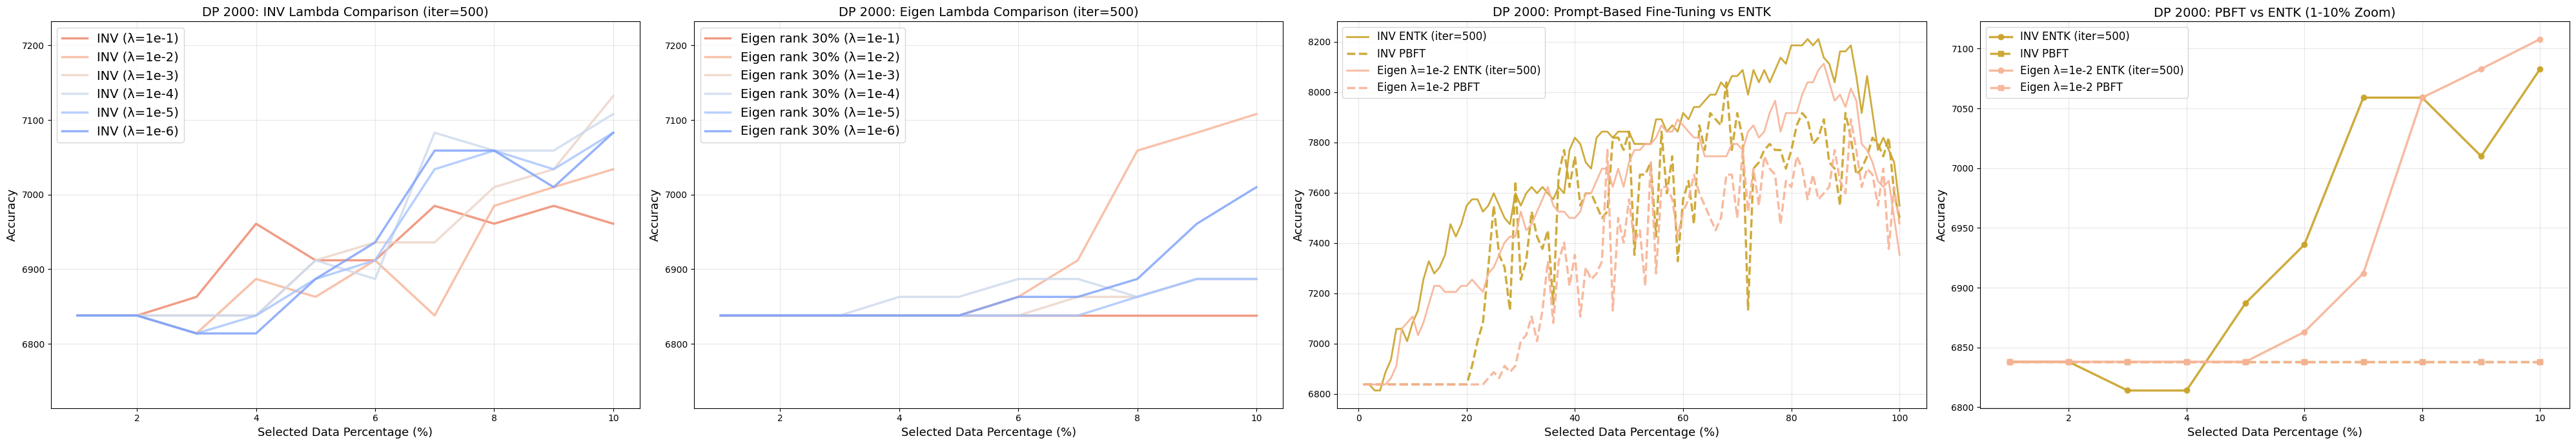

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6838, 6838, 6814, 6814, 6887, 6936, 7059, 7059, 7010, 7083, 7132, 7255, 7328, 7279, 7304, 7353, 7475, 7426, 7475, 7549, 7574, 7574, 7525, 7549, 7598, 7549, 7500, 7475, 7598, 7549, 7598, 7623, 7598, 7623, 7598, 7574, 7623, 7598, 7770, 7819, 7794, 7721, 7696, 7819, 7843, 7843, 7819, 7843, 7843, 7843, 7794, 7794, 7794, 7794, 7892, 7892, 7843, 7868, 7843, 7917, 7892, 7941, 7941, 7966, 7990, 7990, 8039, 8015, 8064, 8064, 8088, 7990, 8088, 8039, 8088, 8039, 8088, 8137, 8113, 8186, 8186, 8186, 8211, 8186, 8211, 8137, 8113, 8039, 8162, 8162, 8186, 8064, 7917, 8064, 7917, 7770, 7819, 7770, 7721, 7549]
inv_lam1e_5      = [6838, 6838, 6814, 6838, 6887, 6912, 7034, 7059, 7034, 7083, 7132, 7206, 7328, 7304, 7279, 7353, 7426, 7475, 7475, 7549, 7574, 7525, 7525, 7525, 7549, 7525, 7500, 7500, 7500, 7525, 7623, 7623, 7598, 7574, 7549, 7549, 7598, 7598, 7672, 7770, 7745, 7721, 7770, 7770, 7843, 7868, 7819, 7892, 7819, 7843, 7819, 7819, 7843, 7819, 7892, 7868, 7892, 7819, 7794, 7868, 7868, 7941, 7941, 7990, 7990, 7990, 7990, 8015, 8015, 8015, 8039, 8088, 8064, 8088, 8039, 8064, 8113, 8088, 8113, 8162, 8162, 8211, 8211, 8186, 8235, 8137, 8137, 8137, 8162, 8162, 8137, 8064, 8015, 8064, 7917, 7819, 7819, 7819, 7721, 7549]
inv_lam1e_4      = [6838, 6838, 6838, 6838, 6912, 6887, 7083, 7059, 7059, 7108, 7181, 7230, 7328, 7304, 7304, 7451, 7500, 7500, 7500, 7574, 7525, 7574, 7598, 7623, 7623, 7549, 7475, 7500, 7475, 7500, 7623, 7623, 7574, 7598, 7623, 7672, 7672, 7721, 7721, 7745, 7721, 7696, 7721, 7745, 7819, 7819, 7819, 7794, 7794, 7819, 7868, 7868, 7892, 7843, 7868, 7868, 7843, 7843, 7819, 7868, 7843, 7892, 7941, 7990, 8039, 8088, 7966, 8015, 8015, 8064, 8137, 8088, 8039, 8064, 8015, 8039, 8088, 8137, 8137, 8137, 8137, 8186, 8211, 8137, 8186, 8113, 8137, 8039, 8113, 8186, 8113, 8015, 7941, 8015, 7892, 7794, 7794, 7843, 7745, 7549]  
inv_lam1e_3      = [6838, 6838, 6838, 6838, 6912, 6936, 6936, 7010, 7034, 7132, 7206, 7255, 7206, 7279, 7377, 7402, 7451, 7500, 7549, 7549, 7525, 7525, 7525, 7500, 7500, 7500, 7525, 7500, 7500, 7525, 7549, 7549, 7549, 7647, 7696, 7721, 7721, 7721, 7794, 7819, 7770, 7794, 7770, 7745, 7819, 7843, 7794, 7819, 7843, 7892, 7941, 7868, 7843, 7892, 7843, 7868, 7843, 7843, 7843, 7819, 7966, 7990, 7941, 7966, 7990, 7990, 8039, 8039, 7990, 8039, 7990, 8015, 8113, 8088, 8088, 8015, 8015, 8113, 8088, 8113, 8137, 8113, 8162, 8211, 8186, 8186, 8137, 8064, 8064, 8039, 8088, 8015, 7990, 7990, 7990, 7941, 7696, 7794, 7696, 7525]      
inv_lam1e_2      = [6838, 6838, 6814, 6887, 6863, 6912, 6838, 6985, 7010, 7034, 7034, 7059, 7157, 7206, 7279, 7255, 7328, 7255, 7255, 7328, 7377, 7426, 7426, 7475, 7500, 7525, 7500, 7525, 7574, 7574, 7574, 7525, 7574, 7696, 7672, 7647, 7672, 7721, 7745, 7745, 7721, 7770, 7794, 7843, 7892, 7868, 7868, 7819, 7868, 7794, 7819, 7843, 7843, 7868, 7819, 7843, 7794, 7770, 7745, 7770, 7794, 7843, 7868, 7966, 7990, 7990, 7966, 8064, 8064, 8064, 8064, 8113, 8064, 8113, 8113, 8064, 8113, 8088, 8039, 8088, 8113, 8113, 8137, 8039, 8137, 8137, 8113, 8088, 8113, 8039, 8088, 8064, 7917, 7917, 8064, 7892, 7770, 7770, 7696, 7549] 
inv_lam1e_1      = [6838, 6838, 6863, 6961, 6912, 6912, 6985, 6961, 6985, 6961, 7010, 6961, 6961, 7034, 7083, 7034, 7059, 7132, 7157, 7206, 7181, 7157, 7255, 7353, 7353, 7255, 7304, 7402, 7402, 7451, 7549, 7549, 7451, 7525, 7574, 7549, 7647, 7721, 7721, 7647, 7696, 7745, 7721, 7819, 7794, 7819, 7721, 7770, 7843, 7819, 7843, 7770, 7770, 7794, 7794, 7868, 7917, 7868, 7892, 7917, 7917, 7941, 7917, 7966, 7892, 7892, 7892, 7917, 7966, 7966, 8015, 8064, 8088, 8064, 8113, 8088, 8064, 8088, 8015, 7990, 8015, 8064, 8162, 8162, 8113, 8162, 8088, 8113, 8088, 7990, 8015, 7990, 8015, 7990, 7941, 7745, 7770, 7819, 7721, 7623]      
eigen_lam1e_6    = [6838, 6838, 6838, 6838, 6838, 6863, 6863, 6887, 6961, 7010, 6936, 6936, 7157, 7206, 7377, 7304, 7328, 7328, 7402, 7255, 7206, 7230, 7255, 7206, 7279, 7402, 7255, 7377, 6936, 6054, 6667, 6936, 7059, 7230, 7475, 7525, 7672, 7623, 7598, 7574, 7623, 7745, 7672, 7647, 7770, 7868, 7892, 7843, 7868, 7843, 7941, 7868, 7745, 7745, 7745, 7696, 7721, 7721, 7721, 7819, 7868, 7917, 7868, 7843, 7917, 7917, 7941, 7770, 7819, 7770, 7843, 7819, 7941, 7941, 7868, 7868, 7819, 7868, 7917, 7868, 7941, 8015, 8015, 8113, 8015, 8039, 8015, 7966, 7966, 7892, 7917, 7892, 7721, 7770, 7672, 7696, 7598, 7598, 7500, 7328]
eigen_lam1e_5    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6863, 6887, 6887, 6912, 6887, 6887, 6863, 6912, 6912, 6936, 6985, 7083, 7059, 7108, 7206, 7132, 7157, 7181, 7181, 7108, 6740, 6838, 6667, 6936, 7157, 7206, 7475, 7426, 7475, 7377, 7377, 7574, 7549, 7574, 7745, 7819, 7794, 7868, 7917, 7990, 7966, 7917, 7966, 8039, 7892, 7819, 7868, 7843, 7892, 7819, 7917, 7868, 7770, 7843, 7917, 8015, 8039, 7966, 7892, 7843, 7819, 7770, 7819, 7794, 7819, 7843, 7917, 7892, 7868, 7843, 7917, 7966, 7966, 8015, 7966, 8137, 7966, 7941, 7966, 7917, 7843, 7941, 7966, 7917, 7843, 7794, 7770, 7672, 7598, 7598, 7549, 7500, 7328]
eigen_lam1e_4    = [6838, 6838, 6838, 6863, 6863, 6887, 6887, 6863, 6887, 6887, 6887, 6912, 6912, 7059, 6936, 7034, 7108, 7206, 7525, 7451, 7475, 7598, 7402, 7475, 7549, 7255, 7304, 7083, 6838, 6838, 6961, 7255, 7475, 7353, 7549, 7525, 7525, 7672, 7721, 7819, 7770, 7794, 7794, 7696, 7745, 7868, 7868, 7917, 7868, 7794, 7917, 7941, 7917, 7868, 7868, 7917, 7868, 7941, 7794, 7745, 7843, 7843, 7770, 7745, 7819, 7819, 7868, 7794, 7745, 7819, 7819, 7892, 7966, 7917, 7966, 7917, 7941, 7892, 7843, 7819, 7892, 7917, 7966, 7917, 8039, 8039, 7990, 8015, 7917, 7819, 7794, 7794, 7721, 7770, 7672, 7623, 7598, 7598, 7525, 7328]
eigen_lam1e_3    = [6838, 6838, 6838, 6838, 6838, 6838, 6863, 6863, 6887, 6887, 7034, 7034, 7010, 7010, 7132, 7132, 7132, 7181, 7230, 7181, 7353, 7328, 7279, 7255, 7377, 7328, 7304, 7377, 7475, 7475, 7525, 7500, 7475, 7475, 7475, 7819, 7819, 7843, 7770, 7696, 7794, 7696, 7696, 7745, 7672, 7770, 7819, 7819, 7770, 7672, 7721, 7770, 7794, 7819, 7721, 7770, 7843, 7843, 7917, 7917, 7990, 7868, 7794, 7966, 7990, 7843, 7794, 7843, 7819, 7794, 7819, 7892, 7917, 7966, 8015, 7966, 8088, 8039, 8039, 8039, 7917, 8015, 7990, 7990, 7990, 7941, 7941, 7990, 7917, 8015, 7819, 7819, 7794, 7819, 7672, 7623, 7623, 7598, 7500, 7328]
eigen_lam1e_2    = [6838, 6838, 6838, 6838, 6838, 6863, 6912, 7059, 7083, 7108, 7034, 7083, 7157, 7230, 7230, 7206, 7206, 7206, 7230, 7230, 7255, 7230, 7206, 7279, 7304, 7353, 7402, 7426, 7426, 7525, 7451, 7475, 7525, 7574, 7623, 7549, 7525, 7525, 7500, 7500, 7525, 7598, 7598, 7647, 7696, 7696, 7623, 7696, 7623, 7721, 7770, 7770, 7794, 7794, 7819, 7868, 7843, 7843, 7892, 7868, 7843, 7819, 7819, 7745, 7745, 7745, 7745, 7745, 7794, 7794, 7770, 7843, 7868, 7819, 7843, 7917, 7966, 7843, 7917, 7917, 7917, 7990, 8039, 8039, 8088, 8113, 8039, 7966, 7990, 7941, 8015, 7966, 7794, 7770, 7721, 7647, 7623, 7647, 7500, 7353]
eigen_lam1e_1    = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6887, 6936, 6961, 6961, 6912, 6936, 6961, 6961, 6985, 7034, 7034, 7059, 7108, 7108, 7206, 7328, 7230, 7255, 7230, 7255, 7230, 7230, 7230, 7230, 7255, 7255, 7255, 7255, 7255, 7304, 7304, 7500, 7525, 7500, 7525, 7525, 7525, 7549, 7500, 7525, 7598, 7574, 7525, 7549, 7525, 7574, 7525, 7525, 7549, 7549, 7549, 7549, 7525, 7500, 7475, 7549, 7451, 7500, 7500, 7598, 7696, 7721, 7721, 7696, 7721, 7721, 7819, 7892, 7794, 7892, 7868, 7941, 7966, 7966, 7941, 7868, 7892, 7941, 7892, 7941, 7819, 7745, 7794, 7721, 7745, 7721, 7696, 7598, 7475]

# Prediction with random shapley values
r_inv_lam1e_6     = [6593, 6593, 6397, 6422, 6299, 6422, 6642, 6691, 6593, 6691, 6716, 6838, 6740, 6691, 6618, 6642, 6863, 6814, 6740, 6863, 6985, 7059, 7034, 7034, 6985, 7157, 7181, 7157, 7230, 7328, 7157, 7206, 7255, 7181, 7083, 7132, 7328, 7157, 7255, 7059, 7206, 7108, 7108, 6961, 6985, 7010, 7083, 7108, 7059, 6985, 7034, 7083, 6985, 6912, 6961, 7108, 7108, 7206, 7059, 7059, 7010, 7108, 7059, 7108, 7132, 7206, 7132, 7206, 7181, 7230, 7230, 7181, 7279, 7255, 7230, 7181, 7157, 7230, 7108, 7181, 7230, 7206, 7181, 7181, 7157, 7083, 7132, 7304, 7426, 7328, 7304, 7304, 7377, 7328, 7377, 7426, 7426, 7500, 7500, 7549]
r_inv_lam1e_5     = [6593, 6593, 6397, 6422, 6299, 6422, 6642, 6691, 6593, 6691, 6716, 6838, 6740, 6691, 6618, 6642, 6863, 6814, 6740, 6863, 6985, 7059, 7034, 7034, 6985, 7157, 7181, 7157, 7230, 7328, 7157, 7206, 7255, 7181, 7083, 7132, 7328, 7157, 7255, 7059, 7206, 7108, 7108, 6961, 6985, 7010, 7083, 7108, 7059, 6985, 7034, 7083, 6985, 6912, 6961, 7108, 7108, 7206, 7059, 7059, 7010, 7108, 7059, 7108, 7132, 7206, 7132, 7206, 7181, 7230, 7230, 7181, 7279, 7255, 7230, 7181, 7157, 7230, 7108, 7181, 7230, 7206, 7181, 7181, 7157, 7083, 7132, 7304, 7426, 7328, 7304, 7304, 7377, 7328, 7377, 7426, 7426, 7500, 7500, 7549]
r_inv_lam1e_4     = [6593, 6593, 6397, 6397, 6299, 6422, 6642, 6691, 6593, 6691, 6716, 6838, 6740, 6691, 6618, 6642, 6863, 6814, 6740, 6863, 6985, 7059, 7034, 7034, 6985, 7157, 7181, 7157, 7230, 7328, 7157, 7206, 7255, 7181, 7083, 7132, 7328, 7157, 7255, 7059, 7206, 7108, 7108, 6961, 6985, 7010, 7083, 7108, 7059, 7010, 7034, 7083, 6985, 6912, 6961, 7108, 7108, 7206, 7059, 7059, 7010, 7108, 7059, 7108, 7132, 7206, 7132, 7206, 7181, 7230, 7230, 7181, 7279, 7255, 7230, 7206, 7157, 7230, 7108, 7181, 7230, 7206, 7181, 7181, 7157, 7083, 7132, 7304, 7426, 7328, 7304, 7328, 7377, 7328, 7377, 7426, 7426, 7500, 7500, 7549]    
r_inv_lam1e_3     = [6593, 6593, 6397, 6397, 6299, 6422, 6642, 6691, 6569, 6691, 6716, 6838, 6765, 6716, 6593, 6642, 6838, 6814, 6765, 6838, 6985, 7059, 7034, 7034, 6985, 7181, 7181, 7157, 7230, 7353, 7157, 7230, 7255, 7206, 7083, 7108, 7328, 7181, 7255, 7083, 7181, 7108, 7108, 6961, 6985, 7010, 7083, 7108, 7059, 7010, 7034, 7132, 6985, 6936, 6961, 7108, 7132, 7206, 7083, 7059, 7034, 7108, 7059, 7108, 7157, 7181, 7108, 7206, 7181, 7255, 7255, 7157, 7279, 7279, 7206, 7206, 7181, 7230, 7132, 7181, 7230, 7230, 7206, 7181, 7181, 7083, 7132, 7304, 7426, 7328, 7304, 7328, 7377, 7328, 7377, 7426, 7451, 7500, 7475, 7525] 
r_inv_lam1e_2     = [6618, 6593, 6373, 6397, 6275, 6446, 6691, 6667, 6544, 6691, 6691, 6887, 6789, 6740, 6593, 6593, 6912, 6814, 6838, 6838, 6985, 7108, 7059, 7034, 7059, 7206, 7181, 7206, 7255, 7377, 7255, 7255, 7304, 7206, 7132, 7083, 7304, 7181, 7230, 7108, 7181, 7059, 7108, 6961, 7034, 7010, 7083, 7083, 7059, 7034, 7059, 7059, 6985, 7034, 7059, 7059, 7206, 7157, 7083, 7059, 7059, 7108, 6985, 7132, 7206, 7181, 7059, 7157, 7181, 7255, 7206, 7132, 7230, 7255, 7255, 7206, 7206, 7279, 7181, 7279, 7328, 7206, 7230, 7157, 7181, 7083, 7230, 7279, 7402, 7402, 7353, 7402, 7402, 7426, 7426, 7426, 7525, 7500, 7525, 7549]   
r_inv_lam1e_1     = [6716, 6667, 6520, 6495, 6373, 6593, 6667, 6740, 6716, 6961, 6912, 6985, 6961, 6863, 6765, 6887, 6961, 6887, 7083, 6985, 7181, 7230, 7206, 7230, 7230, 7353, 7255, 7255, 7279, 7402, 7328, 7353, 7451, 7279, 7328, 7304, 7377, 7500, 7451, 7304, 7132, 7132, 7181, 7108, 7108, 7157, 7157, 7157, 7181, 7157, 7132, 7157, 7157, 7034, 7132, 7230, 7304, 7255, 7108, 7108, 7059, 7108, 7059, 7279, 7328, 7255, 7279, 7279, 7304, 7304, 7181, 7206, 7279, 7328, 7377, 7279, 7206, 7230, 7279, 7279, 7255, 7230, 7255, 7353, 7353, 7304, 7402, 7353, 7279, 7255, 7279, 7304, 7426, 7451, 7500, 7475, 7598, 7525, 7500, 7623] 
r_eigen_lam1e_6   = [6495, 6446, 6152, 6127, 6103, 6324, 6299, 6373, 6225, 6201, 6422, 6103, 6054, 5931, 5760, 6201, 6225, 6176, 5931, 6103, 6054, 6078, 6152, 6103, 5833, 5711, 5539, 5196, 5000, 5196, 5221, 5515, 5613, 5417, 6029, 6299, 6103, 6348, 6471, 6544, 6373, 6544, 6299, 6275, 6618, 6593, 6593, 6838, 6691, 6716, 6814, 6667, 6740, 6789, 6618, 6789, 6814, 6863, 7034, 6985, 6985, 7108, 6961, 6985, 6961, 6961, 6985, 7083, 6985, 7108, 7083, 7083, 7206, 7108, 7059, 7108, 7206, 7083, 7108, 7059, 7181, 7181, 7206, 7108, 7083, 7132, 7206, 7132, 7157, 7181, 7304, 7255, 7279, 7255, 7328, 7402, 7230, 7353, 7279, 7328]
r_eigen_lam1e_5   = [6495, 6471, 6176, 6005, 6152, 6324, 6299, 6373, 6250, 6275, 6495, 6176, 6078, 5956, 5784, 6176, 6127, 6103, 5980, 6054, 6054, 6078, 6152, 6176, 5784, 5735, 5588, 5221, 5074, 5441, 5196, 5564, 5588, 5417, 6005, 6299, 6103, 6348, 6471, 6544, 6373, 6544, 6299, 6275, 6618, 6593, 6593, 6838, 6691, 6716, 6814, 6667, 6740, 6789, 6618, 6789, 6814, 6863, 7034, 6985, 6985, 7108, 6961, 6985, 6961, 6961, 6985, 7083, 6985, 7108, 7083, 7083, 7206, 7108, 7059, 7108, 7206, 7083, 7108, 7059, 7181, 7181, 7206, 7108, 7083, 7132, 7206, 7132, 7157, 7181, 7304, 7255, 7279, 7255, 7328, 7402, 7230, 7353, 7279, 7328]
r_eigen_lam1e_4   = [6495, 6471, 6176, 6005, 6176, 6324, 6324, 6373, 6275, 6275, 6446, 6176, 6078, 5956, 5809, 6127, 6103, 6054, 5956, 6078, 6103, 6078, 6225, 6152, 5858, 5858, 5588, 5196, 5294, 5637, 5686, 5711, 5441, 5319, 6054, 6299, 6152, 6348, 6471, 6569, 6373, 6569, 6373, 6275, 6618, 6593, 6593, 6838, 6716, 6716, 6838, 6667, 6740, 6789, 6618, 6789, 6814, 6863, 7034, 6985, 7010, 7108, 6961, 6985, 6961, 6961, 6985, 7083, 6985, 7108, 7083, 7083, 7206, 7108, 7083, 7108, 7206, 7083, 7108, 7059, 7181, 7181, 7206, 7108, 7083, 7132, 7206, 7132, 7157, 7181, 7304, 7255, 7279, 7255, 7328, 7402, 7230, 7353, 7279, 7328]
r_eigen_lam1e_3   = [6495, 6471, 6176, 6005, 6225, 6324, 6348, 6422, 6176, 6324, 6446, 6201, 6152, 6103, 5809, 6103, 6201, 6078, 6005, 6103, 6152, 6078, 6275, 6348, 5956, 5882, 6029, 5564, 5686, 5760, 5735, 5784, 5686, 5833, 6275, 6495, 6397, 6348, 6495, 6789, 6520, 6593, 6471, 6299, 6569, 6593, 6642, 6863, 6789, 6838, 6814, 6667, 6740, 6789, 6618, 6740, 6838, 6887, 7034, 6985, 7059, 7108, 6985, 7034, 6961, 6985, 6985, 7083, 7034, 7108, 7108, 7083, 7230, 7108, 7083, 7132, 7206, 7083, 7083, 7083, 7181, 7181, 7206, 7108, 7083, 7132, 7206, 7132, 7157, 7181, 7304, 7255, 7279, 7255, 7328, 7402, 7230, 7353, 7279, 7328]
r_eigen_lam1e_2   = [6495, 6471, 6176, 6054, 6225, 6299, 6397, 6471, 6275, 6373, 6544, 6299, 6275, 6348, 6005, 6324, 6397, 6348, 6250, 6397, 6373, 6397, 6642, 6667, 6618, 6299, 6324, 6299, 6373, 6422, 6275, 6446, 6446, 6544, 6716, 6765, 6912, 6814, 6887, 6985, 6936, 6912, 6789, 6618, 6691, 6887, 7010, 6985, 7034, 6961, 7083, 6863, 6789, 6863, 6765, 6838, 6863, 7010, 7108, 7108, 7132, 7132, 7108, 7132, 7059, 7108, 7108, 7181, 7059, 7157, 7181, 7206, 7279, 7108, 7108, 7181, 7206, 7157, 7083, 7083, 7181, 7157, 7206, 7132, 7083, 7157, 7157, 7132, 7157, 7206, 7304, 7230, 7304, 7279, 7328, 7426, 7230, 7353, 7304, 7353]
r_eigen_lam1e_1   = [6569, 6569, 6275, 6225, 6275, 6373, 6471, 6642, 6618, 6765, 6667, 6618, 6544, 6716, 6225, 6446, 6618, 6740, 6765, 6765, 6814, 7108, 7083, 7059, 7157, 7230, 7132, 7206, 7108, 7157, 7157, 7181, 7279, 7206, 7083, 7108, 7157, 7108, 7206, 7181, 7328, 7279, 7255, 7059, 7181, 7181, 7132, 7157, 7132, 7132, 7083, 7230, 7255, 7230, 7181, 7230, 7279, 7255, 7377, 7304, 7206, 7304, 7255, 7181, 7279, 7255, 7206, 7206, 7206, 7157, 7230, 7304, 7328, 7328, 7230, 7181, 7230, 7108, 7108, 7157, 7083, 7083, 7279, 7181, 7181, 7206, 7230, 7230, 7230, 7304, 7353, 7353, 7377, 7377, 7377, 7426, 7402, 7451, 7500, 7475]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6912, 7010, 7083, 7304, 7549, 7353, 7304, 7132, 7647, 7255, 7328, 7525, 7426, 7377, 7451, 7157, 7672, 7770, 7623, 7745, 7549, 7598, 7598, 7549, 7500, 7525, 7819, 7819, 7770, 7843, 7353, 7672, 7672, 7721, 7426, 7843, 7598, 7745, 7328, 7574, 7647, 7475, 7868, 7770, 7917, 7892, 7868, 8039, 7770, 7917, 7819, 7132, 7696, 7721, 7770, 7794, 7770, 7770, 7696, 7770, 7868, 7917, 7892, 7794, 7819, 7892, 7721, 7696, 7549, 7917, 7819, 7672, 7696, 7745, 7819, 7794, 7745, 7819, 7598, 7500]
pbft_eigen_lam1e_2 = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6863, 6887, 6863, 6912, 6887, 6912, 7010, 7034, 7108, 7010, 7132, 7328, 7083, 7328, 7402, 7230, 7353, 7108, 7304, 7255, 7279, 7328, 7770, 7132, 7500, 7402, 7574, 7402, 7451, 7230, 7721, 7279, 7623, 7623, 7574, 7426, 7525, 7574, 7672, 7598, 7549, 7500, 7451, 7500, 7672, 7672, 7500, 7770, 7525, 7696, 7549, 7745, 7696, 7672, 7475, 7647, 7623, 7745, 7696, 7574, 7672, 7574, 7598, 7623, 7770, 7647, 7598, 7892, 7770, 7623, 7696, 7672, 7549, 7696, 7377, 7623, 7475]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse to make 1e-1 red, 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1]  # Lambda 1e-2 color (after reversal)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom parameters for 1-10% range
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV lambda comparison (1-10%) =====
ax_left = axes[0]

# Define INV lambda data list
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Lambda Comparison (iter={iteration})', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen lambda comparison (1-10%) =====
ax_middle = axes[1]

# Define Eigen lambda data list
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Lambda Comparison (iter={iteration})', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)

# Synchronize y-axis range for (1,1) and (1,2)
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

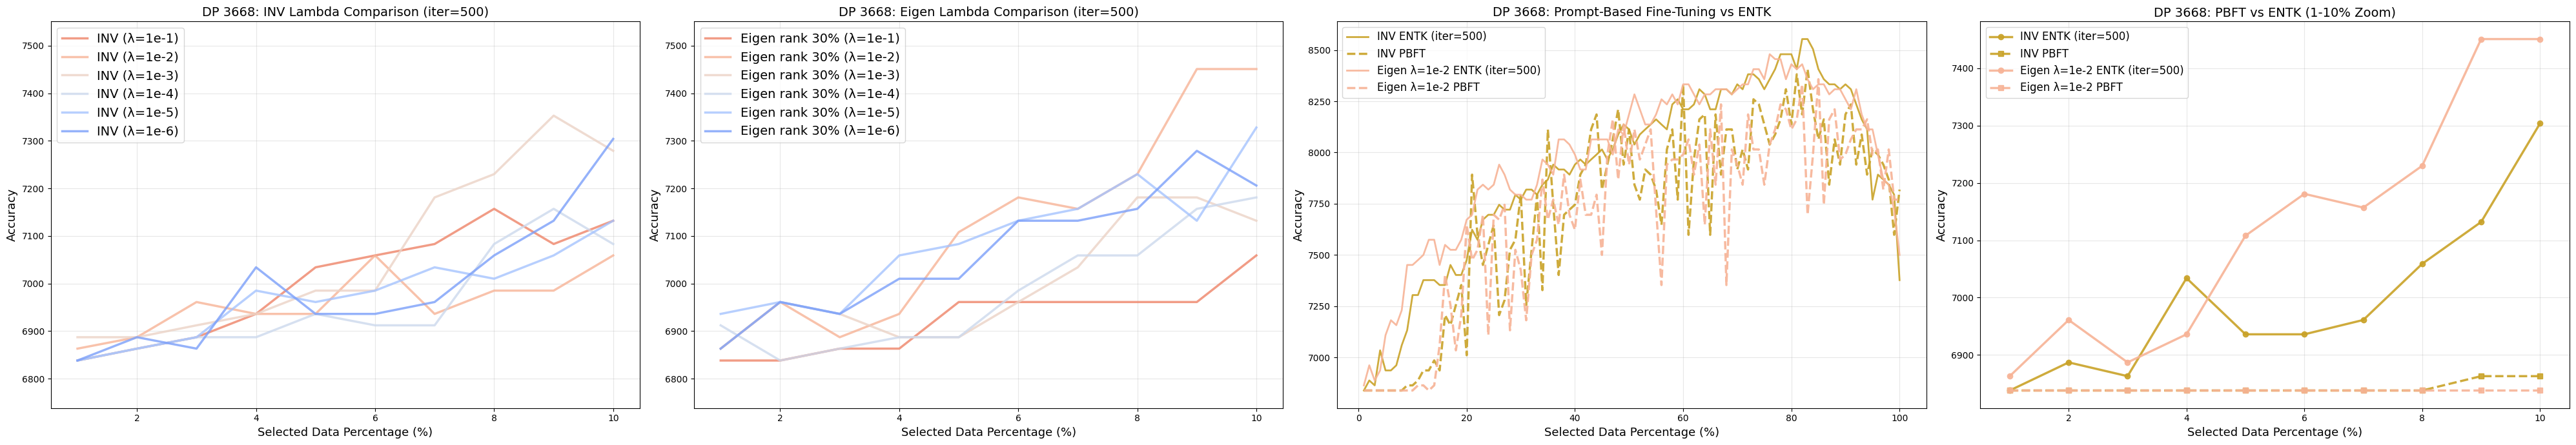

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 3668
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6838, 6887, 6863, 7034, 6936, 6936, 6961, 7059, 7132, 7304, 7304, 7377, 7377, 7377, 7353, 7353, 7451, 7402, 7402, 7475, 7623, 7574, 7672, 7696, 7696, 7745, 7721, 7721, 7794, 7770, 7819, 7819, 7794, 7843, 7868, 7941, 7917, 7917, 7892, 7941, 7966, 7941, 7966, 7990, 8015, 7966, 8015, 8088, 8137, 8113, 8039, 8088, 8113, 8137, 8162, 8137, 8113, 8235, 8260, 8211, 8211, 8235, 8309, 8284, 8211, 8211, 8309, 8309, 8284, 8333, 8309, 8382, 8382, 8358, 8309, 8358, 8407, 8480, 8480, 8480, 8407, 8554, 8554, 8505, 8407, 8358, 8333, 8333, 8309, 8333, 8309, 8235, 8162, 8113, 7770, 7892, 7868, 7843, 7794, 7377]
inv_lam1e_5      = [6838, 6863, 6887, 6985, 6961, 6985, 7034, 7010, 7059, 7132, 7304, 7377, 7377, 7328, 7328, 7402, 7402, 7475, 7475, 7598, 7549, 7549, 7745, 7696, 7647, 7794, 7721, 7770, 7745, 7745, 7843, 7917, 7941, 7941, 7892, 7892, 7941, 7941, 7941, 7892, 7917, 7966, 7966, 7990, 8015, 8015, 7941, 8015, 8015, 8039, 8064, 8064, 8064, 8064, 8088, 8113, 8137, 8088, 8186, 8186, 8162, 8211, 8211, 8186, 8186, 8235, 8235, 8235, 8284, 8309, 8309, 8358, 8382, 8382, 8382, 8382, 8358, 8554, 8578, 8505, 8480, 8529, 8382, 8407, 8431, 8505, 8407, 8382, 8284, 8407, 8235, 8211, 8211, 8064, 7770, 7843, 7868, 7794, 7794, 7377]      
inv_lam1e_4      = [6838, 6863, 6887, 6887, 6936, 6912, 6912, 7083, 7157, 7083, 7206, 7304, 7377, 7353, 7328, 7353, 7451, 7451, 7574, 7598, 7598, 7598, 7647, 7647, 7672, 7672, 7770, 7794, 7843, 7892, 7892, 7868, 7892, 7868, 7819, 7917, 7892, 7941, 8039, 8039, 8015, 8015, 7990, 7966, 7941, 7990, 8015, 8015, 8064, 8088, 8088, 8088, 8039, 8039, 8088, 8015, 8088, 8186, 8186, 8186, 8186, 8162, 8260, 8260, 8235, 8260, 8333, 8284, 8309, 8358, 8407, 8431, 8407, 8456, 8456, 8407, 8382, 8382, 8456, 8480, 8456, 8505, 8431, 8456, 8480, 8480, 8431, 8358, 8333, 8431, 8235, 8235, 8039, 8039, 7868, 7819, 7794, 7892, 7892, 7402]     
inv_lam1e_3      = [6887, 6887, 6912, 6936, 6985, 6985, 7181, 7230, 7353, 7279, 7451, 7377, 7475, 7475, 7402, 7475, 7426, 7500, 7647, 7647, 7574, 7672, 7770, 7794, 7966, 7941, 7917, 7941, 7917, 7892, 7892, 7917, 7917, 8015, 7941, 8064, 8064, 8113, 8064, 8113, 8064, 8162, 8162, 8137, 8137, 8162, 8137, 8186, 8162, 8113, 8162, 8162, 8113, 8162, 8186, 8235, 8284, 8309, 8309, 8333, 8333, 8284, 8309, 8260, 8260, 8235, 8260, 8333, 8358, 8358, 8358, 8407, 8358, 8333, 8382, 8382, 8505, 8603, 8554, 8603, 8578, 8554, 8529, 8554, 8554, 8480, 8529, 8456, 8358, 8333, 8333, 8260, 8186, 8064, 7868, 7868, 7794, 7819, 7770, 7598]  
inv_lam1e_2      = [6863, 6887, 6961, 6936, 6936, 7059, 6936, 6985, 6985, 7059, 7230, 7279, 7279, 7426, 7451, 7426, 7451, 7500, 7549, 7574, 7598, 7721, 7721, 7647, 7745, 7770, 7745, 7819, 7892, 7892, 8039, 8113, 8064, 8088, 8064, 8039, 8113, 8137, 8113, 8039, 8088, 8113, 8088, 8064, 8088, 8039, 8064, 8113, 8137, 8186, 8137, 8137, 8162, 8113, 8186, 8064, 8211, 8211, 8186, 8186, 8211, 8186, 8186, 8162, 8186, 8235, 8235, 8284, 8333, 8333, 8333, 8309, 8333, 8284, 8358, 8333, 8382, 8407, 8456, 8431, 8505, 8456, 8407, 8480, 8505, 8407, 8505, 8456, 8456, 8382, 8260, 8137, 8137, 8064, 7892, 7941, 7843, 7868, 7721, 7525] 
inv_lam1e_1      = [6838, 6863, 6887, 6936, 7034, 7059, 7083, 7157, 7083, 7132, 7157, 7132, 7157, 7255, 7304, 7402, 7402, 7549, 7500, 7500, 7623, 7647, 7647, 7745, 7794, 7745, 7721, 7794, 7868, 7941, 7917, 7892, 7892, 7892, 7917, 7892, 7917, 7966, 8015, 7966, 7941, 7966, 8015, 8015, 8064, 8113, 8162, 8137, 8137, 8113, 8113, 8137, 8162, 8162, 8186, 8162, 8186, 8235, 8235, 8186, 8137, 8162, 8235, 8260, 8235, 8260, 8284, 8284, 8260, 8309, 8309, 8358, 8309, 8333, 8333, 8407, 8333, 8431, 8382, 8358, 8358, 8407, 8358, 8431, 8358, 8407, 8358, 8382, 8333, 8186, 8309, 8211, 8186, 8088, 7966, 7892, 7843, 7794, 7745, 7672] 
eigen_lam1e_6    = [6863, 6961, 6936, 7010, 7010, 7132, 7132, 7157, 7279, 7206, 7328, 7402, 7500, 7500, 7549, 7672, 7623, 7647, 7696, 7647, 7525, 7500, 7328, 7353, 7377, 7304, 7157, 7034, 6716, 6275, 6495, 6765, 7426, 7500, 7377, 7647, 7672, 7843, 7990, 7990, 8088, 8260, 8211, 8113, 8186, 8211, 8211, 8162, 8162, 8284, 8333, 8260, 8235, 8162, 8186, 8235, 8260, 8333, 8260, 8162, 8162, 8260, 8235, 8137, 8186, 8284, 8309, 8260, 8284, 8358, 8382, 8407, 8309, 8382, 8162, 8186, 8211, 8260, 8309, 8260, 8309, 8260, 8333, 8358, 8235, 8162, 8211, 8284, 8235, 8162, 8137, 8137, 8113, 8039, 7966, 7917, 7819, 7794, 7647, 7500]
eigen_lam1e_5    = [6936, 6961, 6936, 7059, 7083, 7132, 7157, 7230, 7132, 7328, 7377, 7475, 7500, 7598, 7623, 7647, 7598, 7696, 7647, 7696, 7770, 7745, 7745, 7745, 7647, 7623, 7475, 7402, 6814, 6152, 6471, 7132, 7451, 7500, 7770, 7770, 7990, 7917, 7892, 8015, 8015, 8113, 7990, 8088, 8137, 7966, 8015, 8015, 8088, 8211, 8284, 8137, 8235, 8309, 8235, 8333, 8309, 8284, 8358, 8358, 8382, 8333, 8260, 8284, 8333, 8407, 8358, 8431, 8431, 8480, 8480, 8382, 8333, 8358, 8358, 8309, 8309, 8260, 8211, 8260, 8284, 8309, 8284, 8162, 8260, 8260, 8309, 8309, 8333, 8235, 8211, 8137, 8113, 8113, 7966, 7843, 7819, 7745, 7623, 7500]
eigen_lam1e_4    = [6912, 6838, 6863, 6887, 6887, 6985, 7059, 7059, 7157, 7181, 7157, 7206, 7255, 7230, 7426, 7426, 7377, 7500, 7525, 7402, 7598, 7672, 7770, 7623, 7672, 7500, 7402, 7574, 7549, 7696, 7574, 7132, 7574, 7574, 7475, 7794, 7794, 7794, 7941, 8039, 7941, 7990, 7990, 7966, 7941, 8039, 8137, 8235, 8137, 8088, 8162, 8162, 8186, 8235, 8211, 8333, 8284, 8309, 8284, 8333, 8333, 8309, 8260, 8407, 8407, 8456, 8358, 8382, 8358, 8333, 8480, 8407, 8382, 8284, 8333, 8235, 8333, 8309, 8309, 8333, 8407, 8382, 8382, 8382, 8333, 8309, 8235, 8284, 8235, 8260, 8211, 8235, 8088, 8088, 7966, 7966, 7843, 7794, 7598, 7500]
eigen_lam1e_3    = [6863, 6961, 6936, 6887, 6887, 6961, 7034, 7181, 7181, 7132, 7157, 7206, 7157, 7230, 7377, 7647, 7647, 7696, 7745, 7647, 7794, 7843, 7745, 7868, 7696, 7990, 7990, 7941, 7990, 7868, 7966, 7770, 7745, 7721, 7770, 7966, 7966, 7966, 8064, 8088, 8088, 8162, 8137, 8137, 8211, 8113, 8162, 8137, 8039, 8088, 8039, 8088, 8162, 8064, 8162, 8137, 8162, 8211, 8137, 8137, 8113, 8137, 8137, 8211, 8235, 8284, 8309, 8333, 8211, 8235, 8235, 8235, 8235, 8162, 8260, 8284, 8358, 8260, 8260, 8382, 8382, 8431, 8358, 8333, 8260, 8333, 8284, 8284, 8333, 8284, 8260, 8235, 8015, 7990, 7966, 7941, 7892, 7721, 7672, 7500]
eigen_lam1e_2    = [6863, 6961, 6887, 6936, 7108, 7181, 7157, 7230, 7451, 7451, 7475, 7500, 7574, 7574, 7451, 7549, 7525, 7525, 7574, 7672, 7696, 7819, 7843, 7819, 7843, 7941, 7892, 7819, 7794, 7794, 7770, 7770, 7843, 7966, 7941, 7892, 8064, 8064, 8039, 7990, 7917, 7917, 8064, 8064, 8064, 8064, 7990, 8113, 8088, 8186, 8284, 8211, 8137, 8137, 8186, 8260, 8235, 8284, 8235, 8333, 8333, 8284, 8235, 8284, 8284, 8309, 8309, 8309, 8284, 8309, 8333, 8333, 8407, 8407, 8358, 8480, 8456, 8456, 8358, 8431, 8407, 8431, 8358, 8309, 8333, 8333, 8284, 8309, 8309, 8260, 8211, 8309, 8186, 8113, 8113, 7990, 7868, 7843, 7721, 7500]
eigen_lam1e_1    = [6838, 6838, 6863, 6863, 6961, 6961, 6961, 6961, 6961, 7059, 7108, 7108, 7132, 7279, 7255, 7304, 7402, 7402, 7475, 7451, 7377, 7377, 7500, 7525, 7598, 7647, 7672, 7672, 7696, 7647, 7672, 7745, 7794, 7819, 7843, 7770, 7745, 7819, 7917, 7941, 7990, 8015, 8015, 7917, 7892, 7917, 7941, 7990, 7990, 7990, 7990, 8015, 7990, 8039, 8039, 8015, 8064, 8088, 8113, 8162, 8186, 8186, 8211, 8235, 8235, 8162, 8211, 8211, 8162, 8211, 8235, 8235, 8309, 8333, 8309, 8309, 8260, 8235, 8309, 8235, 8260, 8211, 8235, 8211, 8235, 8162, 8186, 8186, 8162, 8211, 8137, 8113, 8137, 8162, 8064, 7941, 7868, 7868, 7843, 7598]

# Prediction with random shapley values
r_inv_lam1e_6     = [6250, 6103, 6397, 6275, 6250, 6569, 6618, 6765, 6642, 6569, 6691, 6569, 6618, 6814, 6789, 6887, 7010, 6985, 7108, 6887, 6912, 6912, 6936, 6936, 6961, 6936, 6985, 6936, 6985, 6912, 7034, 7034, 6887, 7010, 7108, 7059, 7010, 7059, 7157, 7206, 7059, 6961, 7010, 6985, 7034, 7010, 6985, 7059, 7108, 7083, 7059, 7034, 7083, 7157, 7206, 7255, 6985, 7181, 7132, 7108, 7132, 7157, 7206, 7206, 7304, 7377, 7475, 7451, 7426, 7451, 7475, 7377, 7304, 7255, 7328, 7279, 7230, 7304, 7255, 7353, 7255, 7279, 7279, 7132, 7181, 7157, 7279, 7108, 7132, 7181, 7157, 7255, 7255, 7304, 7328, 7377, 7279, 7353, 7402, 7377]
r_inv_lam1e_5     = [6250, 6103, 6397, 6275, 6250, 6569, 6618, 6765, 6642, 6569, 6691, 6569, 6618, 6814, 6789, 6887, 7010, 6985, 7108, 6887, 6912, 6912, 6936, 6936, 6961, 6936, 6985, 6936, 6985, 6912, 7034, 7034, 6887, 7010, 7108, 7059, 7010, 7059, 7157, 7206, 7059, 6961, 7010, 6985, 7034, 7010, 6985, 7059, 7108, 7083, 7059, 7034, 7083, 7157, 7206, 7255, 6985, 7181, 7132, 7108, 7132, 7157, 7206, 7206, 7304, 7377, 7475, 7451, 7426, 7451, 7475, 7377, 7279, 7230, 7328, 7304, 7255, 7304, 7255, 7377, 7255, 7279, 7279, 7132, 7181, 7181, 7279, 7132, 7132, 7206, 7157, 7230, 7255, 7328, 7328, 7377, 7279, 7353, 7402, 7377] 
r_inv_lam1e_4     = [6250, 6103, 6397, 6275, 6250, 6569, 6618, 6765, 6642, 6569, 6691, 6569, 6618, 6814, 6789, 6887, 7010, 6985, 7108, 6887, 6912, 6912, 6936, 6936, 6961, 6936, 6985, 6961, 6985, 6912, 7034, 7034, 6887, 7010, 7108, 7059, 7010, 7059, 7157, 7206, 7059, 6985, 7010, 6985, 7034, 7010, 6985, 7059, 7108, 7083, 7059, 7034, 7083, 7157, 7206, 7255, 6985, 7157, 7132, 7108, 7132, 7157, 7206, 7206, 7304, 7377, 7475, 7451, 7451, 7451, 7426, 7475, 7328, 7279, 7328, 7304, 7279, 7353, 7328, 7377, 7255, 7230, 7279, 7157, 7279, 7206, 7304, 7181, 7157, 7255, 7230, 7279, 7255, 7353, 7328, 7426, 7377, 7451, 7377, 7402] 
r_inv_lam1e_3     = [6250, 6103, 6397, 6299, 6250, 6569, 6593, 6765, 6618, 6569, 6691, 6569, 6642, 6814, 6789, 6863, 7010, 6985, 7132, 6887, 6912, 6912, 6936, 6961, 6985, 6961, 6985, 6961, 6985, 6912, 7034, 7010, 6887, 7034, 7083, 7059, 7059, 7108, 7157, 7206, 7059, 6985, 7010, 6985, 7059, 7010, 7010, 7108, 7157, 7083, 7083, 7034, 7132, 7157, 7206, 7255, 6985, 7157, 7108, 7108, 7108, 7132, 7206, 7206, 7304, 7377, 7475, 7475, 7475, 7451, 7451, 7426, 7426, 7451, 7426, 7402, 7426, 7402, 7525, 7451, 7377, 7377, 7451, 7353, 7377, 7377, 7451, 7328, 7304, 7328, 7230, 7353, 7279, 7377, 7402, 7525, 7500, 7500, 7475, 7598]
r_inv_lam1e_2     = [6275, 6127, 6422, 6373, 6299, 6593, 6618, 6740, 6765, 6691, 6740, 6544, 6740, 6887, 6765, 6912, 6961, 7034, 7034, 6936, 6912, 6936, 6985, 7059, 7059, 7010, 7010, 6985, 7034, 6961, 7059, 7034, 6936, 7034, 7034, 7132, 7108, 7132, 7181, 7206, 7132, 7034, 7010, 7108, 7157, 7108, 7083, 7181, 7230, 7132, 7132, 7157, 7230, 7255, 7279, 7304, 7059, 7157, 7157, 7230, 7206, 7230, 7279, 7304, 7353, 7426, 7475, 7475, 7500, 7525, 7451, 7525, 7500, 7525, 7549, 7549, 7549, 7525, 7598, 7525, 7500, 7402, 7426, 7402, 7525, 7475, 7525, 7402, 7328, 7328, 7328, 7402, 7402, 7451, 7525, 7500, 7549, 7475, 7426, 7525]
r_inv_lam1e_1     = [6397, 6127, 6667, 6667, 6569, 6642, 6936, 6912, 6765, 6838, 6838, 6691, 6936, 7108, 6961, 7034, 7181, 7132, 7132, 7108, 7328, 7255, 7279, 7206, 7279, 7304, 7255, 7108, 7304, 7157, 7230, 7279, 7157, 7328, 7353, 7475, 7525, 7353, 7451, 7500, 7304, 7304, 7377, 7426, 7279, 7206, 7279, 7255, 7328, 7451, 7500, 7402, 7304, 7426, 7451, 7451, 7402, 7402, 7402, 7377, 7328, 7451, 7426, 7500, 7500, 7426, 7451, 7451, 7549, 7623, 7598, 7525, 7598, 7574, 7500, 7500, 7353, 7475, 7451, 7402, 7402, 7426, 7402, 7402, 7525, 7525, 7475, 7451, 7377, 7402, 7500, 7475, 7475, 7500, 7574, 7598, 7647, 7598, 7623, 7672]
r_eigen_lam1e_6   = [6299, 5735, 6324, 5784, 5833, 6176, 6152, 6225, 6250, 6275, 6176, 5931, 5760, 5833, 5784, 6103, 6201, 6225, 6250, 5956, 5907, 6054, 6152, 6152, 6176, 5809, 5662, 5343, 5343, 5245, 5392, 5539, 5515, 5662, 6078, 6005, 5809, 6054, 5956, 6029, 6348, 6691, 6422, 6569, 6814, 6765, 6936, 6863, 6863, 6887, 6961, 7010, 7034, 7034, 7059, 6985, 7034, 6912, 6789, 7034, 6985, 7132, 7010, 7132, 7230, 7059, 7230, 7108, 7157, 7255, 7304, 7279, 7255, 7328, 7304, 7377, 7304, 7402, 7279, 7426, 7353, 7304, 7377, 7377, 7475, 7451, 7402, 7328, 7402, 7475, 7451, 7402, 7451, 7451, 7500, 7475, 7525, 7451, 7500, 7500]
r_eigen_lam1e_5   = [6324, 5735, 6201, 5637, 5711, 5980, 6275, 6250, 6299, 6397, 6225, 6005, 5858, 5980, 5907, 6127, 6127, 6176, 6201, 6005, 5882, 6005, 6054, 6201, 6152, 5809, 5662, 5343, 5441, 5221, 5564, 5490, 5466, 5637, 6054, 5980, 5809, 6054, 5956, 6029, 6348, 6691, 6422, 6569, 6814, 6765, 6936, 6863, 6863, 6887, 6961, 7010, 7034, 7034, 7059, 6985, 7034, 6912, 6789, 7034, 6985, 7132, 7010, 7132, 7230, 7059, 7230, 7108, 7157, 7255, 7304, 7279, 7255, 7328, 7304, 7377, 7304, 7402, 7279, 7426, 7353, 7304, 7377, 7377, 7475, 7451, 7402, 7328, 7402, 7475, 7451, 7402, 7451, 7451, 7500, 7475, 7525, 7451, 7500, 7500]
r_eigen_lam1e_4   = [6348, 5735, 6225, 5613, 5735, 5980, 6275, 6250, 6275, 6373, 6176, 5980, 5858, 5980, 5907, 6127, 6152, 6201, 6250, 6005, 5882, 5980, 6005, 6152, 6201, 5784, 5760, 5417, 5760, 5588, 5686, 5760, 5441, 5760, 6054, 5980, 5858, 6103, 6005, 6054, 6348, 6667, 6397, 6569, 6814, 6765, 6936, 6887, 6838, 6887, 6961, 7010, 7034, 7034, 7083, 6985, 7034, 6912, 6814, 7034, 6961, 7132, 7010, 7132, 7230, 7059, 7230, 7108, 7157, 7255, 7279, 7279, 7255, 7328, 7304, 7377, 7304, 7402, 7279, 7426, 7353, 7304, 7377, 7377, 7475, 7451, 7402, 7353, 7402, 7475, 7451, 7402, 7451, 7451, 7500, 7475, 7525, 7451, 7500, 7500]
r_eigen_lam1e_3   = [6299, 5711, 6250, 5662, 5735, 6029, 6324, 6225, 6324, 6397, 6176, 6029, 6005, 6103, 6005, 6127, 6250, 6225, 6176, 6029, 6029, 6078, 6250, 6201, 6275, 6103, 5907, 5833, 6029, 6201, 6029, 6005, 6127, 5980, 6250, 6225, 6201, 6275, 6324, 6373, 6397, 6716, 6495, 6691, 6814, 6740, 7010, 6863, 6863, 6961, 6961, 7034, 7034, 7034, 7083, 6985, 7010, 6936, 6814, 7034, 6961, 7083, 7059, 7181, 7206, 7059, 7206, 7108, 7157, 7279, 7279, 7353, 7255, 7328, 7279, 7353, 7304, 7377, 7304, 7426, 7377, 7304, 7377, 7426, 7451, 7451, 7402, 7353, 7402, 7475, 7451, 7402, 7451, 7451, 7500, 7475, 7525, 7475, 7500, 7500]
r_eigen_lam1e_2   = [6324, 5784, 6250, 5809, 5760, 6176, 6397, 6225, 6299, 6446, 6348, 6127, 6275, 6201, 6127, 6446, 6299, 6520, 6373, 6471, 6299, 6520, 6176, 6495, 6716, 6642, 6716, 6667, 6814, 6887, 6838, 6716, 6765, 6887, 6936, 6936, 6912, 6985, 6936, 6887, 6814, 6912, 6912, 6985, 6936, 6936, 7010, 6985, 7059, 7108, 6936, 7034, 7206, 7132, 7083, 6961, 7010, 7059, 7010, 6985, 7010, 7059, 7059, 7255, 7181, 7206, 7132, 7230, 7279, 7353, 7377, 7402, 7353, 7353, 7353, 7353, 7353, 7402, 7328, 7353, 7377, 7353, 7402, 7402, 7426, 7426, 7426, 7451, 7451, 7451, 7500, 7451, 7426, 7525, 7500, 7451, 7525, 7500, 7525, 7500]
r_eigen_lam1e_1   = [6324, 6103, 6740, 6324, 6324, 6667, 6642, 6667, 6618, 6716, 6789, 6618, 6765, 6961, 6789, 7083, 7083, 7108, 7034, 7206, 7181, 7132, 7034, 7132, 7132, 7132, 7108, 7010, 7108, 7083, 7132, 7132, 7230, 7279, 7230, 7402, 7230, 7279, 7279, 7279, 7475, 7328, 7353, 7402, 7402, 7328, 7279, 7304, 7328, 7353, 7353, 7451, 7402, 7353, 7353, 7255, 7279, 7353, 7230, 7181, 7206, 7377, 7328, 7353, 7426, 7328, 7402, 7402, 7426, 7451, 7500, 7402, 7451, 7451, 7426, 7402, 7426, 7475, 7500, 7451, 7426, 7377, 7402, 7402, 7451, 7500, 7475, 7475, 7549, 7574, 7623, 7598, 7574, 7647, 7549, 7598, 7549, 7598, 7623, 7598]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6863, 6863, 6887, 6936, 6936, 6985, 6936, 7206, 7157, 7255, 7353, 7010, 7892, 7598, 7451, 7549, 7647, 7206, 7279, 7525, 7574, 7794, 7255, 7525, 7794, 7328, 8113, 7745, 7402, 7696, 7721, 7745, 7892, 7941, 8113, 8186, 7819, 7941, 8064, 8211, 7941, 8113, 7843, 7770, 7917, 7892, 7819, 7647, 8015, 8113, 7770, 8333, 7598, 7966, 8162, 8186, 7598, 8186, 7892, 8113, 8113, 7917, 8015, 7917, 8260, 8235, 8137, 8039, 8088, 8162, 8309, 8137, 8382, 8186, 8407, 8211, 8064, 8162, 7843, 8064, 7941, 8186, 8235, 7941, 8088, 7892, 8015, 7990, 7941, 7868, 7598, 7819]
pbft_eigen_lam1e_2 = [6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6838, 6863, 6863, 6838, 6863, 7059, 7402, 7255, 7034, 7206, 7647, 7475, 7525, 7696, 7108, 7696, 7672, 7745, 7132, 7525, 7426, 7181, 7500, 7574, 7868, 7672, 7770, 7647, 7892, 7696, 7623, 7868, 7696, 7696, 7794, 7500, 7990, 8162, 7868, 8137, 7941, 8113, 7966, 8039, 8113, 7721, 7353, 7941, 7966, 7966, 7990, 8064, 7892, 8039, 7647, 8113, 7843, 8235, 7353, 8015, 7941, 7843, 8186, 8015, 8015, 7843, 8039, 8113, 8235, 8211, 8113, 8162, 8333, 7696, 7990, 8358, 7745, 8162, 8211, 7966, 7990, 8064, 8113, 8113, 8162, 7990, 8015, 7819, 8015, 7770, 7770]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse to make 1e-1 red, 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1]  # Lambda 1e-2 color (after reversal)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom parameters for 1-10% range
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV lambda comparison (1-10%) =====
ax_left = axes[0]

# Define INV lambda data list
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Lambda Comparison (iter={iteration})', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen lambda comparison (1-10%) =====
ax_middle = axes[1]

# Define Eigen lambda data list
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Lambda Comparison (iter={iteration})', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)

# Synchronize y-axis range for (1,1) and (1,2)
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

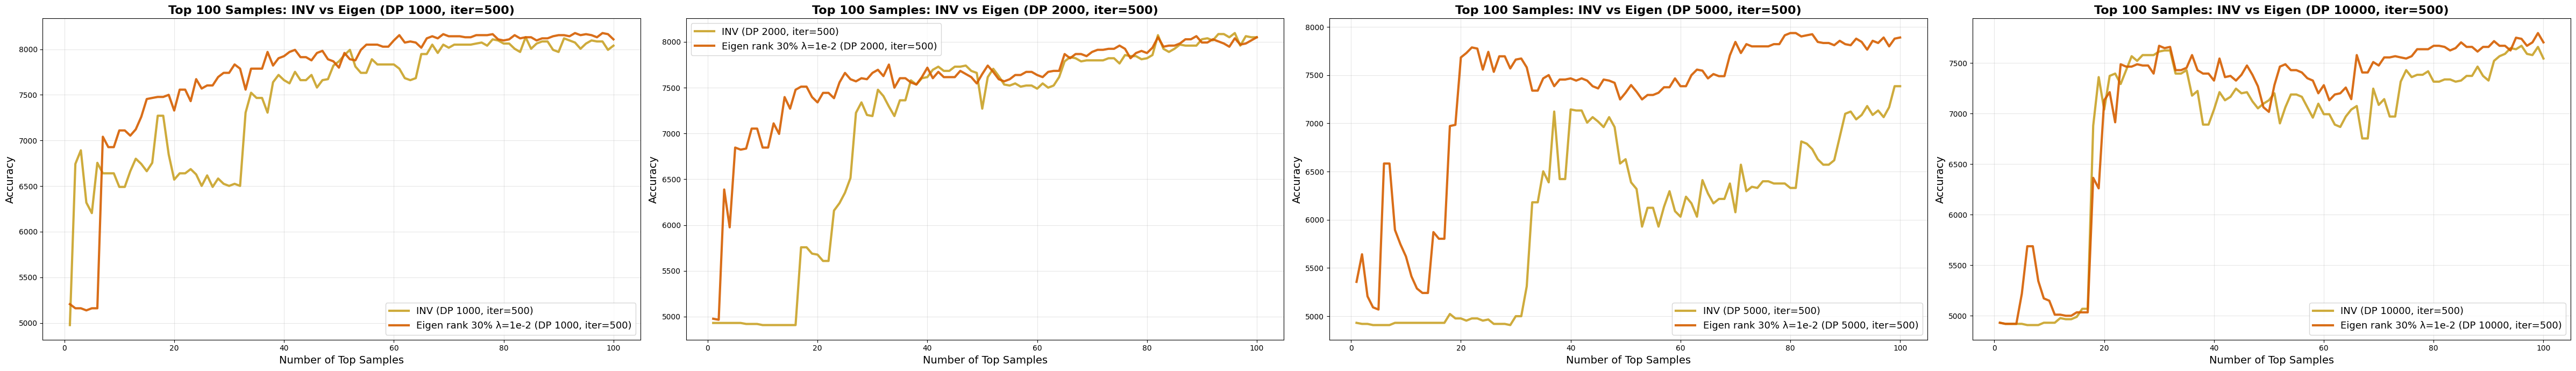

In [ ]:
# top 100 data
data = [i for i in range(1, 101)]
inv_1000              = 
eigen_1000_30_lam1e_2 = 

inv_2000              = 
eigen_2000_30_lam1e_2 = 

inv_5000              = 
eigen_5000_30_lam1e_2 = 

inv_10000              = 
eigen_10000_30_lam1e_2 = 

# Create (1,4) subplots
fig, axes = plt.subplots(1, 4, figsize=(48, 7))

# Color settings
inv_color = '#C9A227'
eigen_color = '#D55E00'  # Orange-red for eigen

# ===== Subplot (1,1): DP 1000 =====
ax_1000 = axes[0]

# Plot INV data (num_dp=1000)
ax_1000.plot(data, inv_1000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 1000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=1000, rank=30%, lambda=1e-2)
ax_1000.plot(data, eigen_1000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 1000, iter=500)', alpha=0.9)

ax_1000.set_xlabel('Number of Top Samples', fontsize=14)
ax_1000.set_ylabel('Accuracy', fontsize=14)
ax_1000.set_title('Top 100 Samples: INV vs Eigen (DP 1000, iter=500)', fontsize=16, fontweight='bold')
ax_1000.legend(fontsize=13, loc='best')
ax_1000.grid(True, alpha=0.3)

# ===== Subplot (1,2): DP 2000 =====
ax_2000 = axes[1]

# Plot INV data (num_dp=2000)
ax_2000.plot(data, inv_2000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 2000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=2000, rank=30%, lambda=1e-2)
ax_2000.plot(data, eigen_2000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 2000, iter=500)', alpha=0.9)

ax_2000.set_xlabel('Number of Top Samples', fontsize=14)
ax_2000.set_ylabel('Accuracy', fontsize=14)
ax_2000.set_title('Top 100 Samples: INV vs Eigen (DP 2000, iter=500)', fontsize=16, fontweight='bold')
ax_2000.legend(fontsize=13, loc='best')
ax_2000.grid(True, alpha=0.3)

# ===== Subplot (1,3): DP 5000 =====
ax_5000 = axes[2]

# Plot INV data (num_dp=5000)
ax_5000.plot(data, inv_5000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 5000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=5000, rank=30%, lambda=1e-2)
ax_5000.plot(data, eigen_5000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 5000, iter=500)', alpha=0.9)

ax_5000.set_xlabel('Number of Top Samples', fontsize=14)
ax_5000.set_ylabel('Accuracy', fontsize=14)
ax_5000.set_title('Top 100 Samples: INV vs Eigen (DP 5000, iter=500)', fontsize=16, fontweight='bold')
ax_5000.legend(fontsize=13, loc='best')
ax_5000.grid(True, alpha=0.3)

# ===== Subplot (1,4): DP 10000 =====
ax_10000 = axes[3]

# Plot INV data (num_dp=10000)
ax_10000.plot(data, inv_10000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 10000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=10000, rank=30%, lambda=1e-2)
ax_10000.plot(data, eigen_10000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 10000, iter=500)', alpha=0.9)

ax_10000.set_xlabel('Number of Top Samples', fontsize=14)
ax_10000.set_ylabel('Accuracy', fontsize=14)
ax_10000.set_title('Top 100 Samples: INV vs Eigen (DP 10000, iter=500)', fontsize=16, fontweight='bold')
ax_10000.legend(fontsize=13, loc='best')
ax_10000.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()